In [89]:
# CELL 1: Install Dependencies (with error handling)
import subprocess
import sys

def install_package(package):
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])
        return True
    except:
        print(f"⚠️ Could not install {package}, but continuing...")
        return False

packages = ['yfinance', 'xgboost', 'torch', 'pandas', 'numpy', 'scikit-learn', 'requests', 'matplotlib', 'seaborn']
for pkg in packages:
    install_package(pkg)

print("✅ Setup complete!")

✅ Setup complete!


In [90]:
# CELL 2: Imports and Setup
import warnings
warnings.filterwarnings('ignore')

import random
import time
import json
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from pathlib import Path
from itertools import combinations

import torch
import torch.nn as nn
import yfinance as yf
import xgboost as xgb
import requests

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("✅ All imports successful!")

✅ All imports successful!


In [91]:
# CELL 3: Dynamic Configuration
def generate_dynamic_config():
    """Generate fresh random configuration for each run"""

    ADDITIONAL_CRYPTO_POOL = [
        {'symbol': 'SOL', 'name': 'Solana'},
        {'symbol': 'DOGE', 'name': 'Dogecoin'},
        {'symbol': 'ADA', 'name': 'Cardano'},
        {'symbol': 'XRP', 'name': 'Ripple'},
        {'symbol': 'LTC', 'name': 'Litecoin'},
        {'symbol': 'LINK', 'name': 'Chainlink'},
    ]

    ADDITIONAL_STOCK_POOL = ['MSFT', 'GOOGL', 'TSLA', 'AMZN', 'NVDA', 'META', 'NFLX']

    NUM_ADDITIONAL_CRYPTO = random.randint(0, 2)
    NUM_ADDITIONAL_STOCK = random.randint(0, 1)
    CURRENT_HISTORICAL_DAYS = random.randint(180, 365)

    FETCH_CONFIG = {
        'crypto': [
            {'symbol': 'BTC', 'name': 'Bitcoin'},
            {'symbol': 'ETH', 'name': 'Ethereum'},
        ],
        'stock': ['AAPL']
    }

    random.shuffle(ADDITIONAL_CRYPTO_POOL)
    for i in range(min(NUM_ADDITIONAL_CRYPTO, len(ADDITIONAL_CRYPTO_POOL))):
        FETCH_CONFIG['crypto'].append(ADDITIONAL_CRYPTO_POOL[i])

    random.shuffle(ADDITIONAL_STOCK_POOL)
    for i in range(min(NUM_ADDITIONAL_STOCK, len(ADDITIONAL_STOCK_POOL))):
        FETCH_CONFIG['stock'].append(ADDITIONAL_STOCK_POOL[i])

    print('='*60)
    print('⚙️ DYNAMIC CONFIGURATION')
    print('='*60)
    print(f'Run ID: {hashlib.md5(str(time.time()).encode()).hexdigest()[:8]}')
    print(f'Historical Days: {CURRENT_HISTORICAL_DAYS}')
    print(f'Cryptocurrencies: {[a["symbol"] for a in FETCH_CONFIG["crypto"]]}')
    print(f'Stocks: {FETCH_CONFIG["stock"]}')
    print('='*60)

    return FETCH_CONFIG, CURRENT_HISTORICAL_DAYS

FETCH_CONFIG, CURRENT_HISTORICAL_DAYS = generate_dynamic_config()

⚙️ DYNAMIC CONFIGURATION
Run ID: 7377828f
Historical Days: 314
Cryptocurrencies: ['BTC', 'ETH', 'ADA']
Stocks: ['AAPL']


In [92]:
# CELL 4: Data Fetching with Cache
CACHE_DIR = Path('/tmp/xchain_cache')
CACHE_DIR.mkdir(exist_ok=True)

def fetch_asset_data(symbol, asset_type='crypto', days=180):
    """Fetch data with caching"""

    # FIX: Handle special cases for Polygon/MATIC
    if symbol == 'POL':
        ticker_symbol = "MATIC-USD"  # Polygon is MATIC on Yahoo Finance
    elif asset_type == 'crypto':
        ticker_symbol = f"{symbol}-USD"
    else:
        ticker_symbol = symbol

    cache_file = CACHE_DIR / f"{symbol}_{days}.json"

    if cache_file.exists():
        age = time.time() - cache_file.stat().st_mtime
        if age < 1800:
            try:
                with open(cache_file, 'r') as f:
                    data = json.load(f)
                if 'historical' in data:
                    data['historical'] = pd.DataFrame(data['historical'])
                    data['historical']['timestamp'] = pd.to_datetime(data['historical']['timestamp'])
                    data['historical'].set_index('timestamp', inplace=True)
                print(f'  📦 {symbol}: from cache')
                return data
            except:
                pass

    try:
        ticker_symbol = f"{symbol}-USD" if asset_type == 'crypto' else symbol
        ticker = yf.Ticker(ticker_symbol)
        hist = ticker.history(period=f'{days}d', interval='1d')

        if hist.empty or len(hist) < 10:
            raise ValueError(f"No data for {symbol}")

        current_price = float(hist['Close'].iloc[-1])
        prev_price = float(hist['Close'].iloc[-2]) if len(hist) > 1 else current_price
        change_24h = ((current_price - prev_price) / prev_price) * 100

        df = pd.DataFrame({
            'price': hist['Close'].values,
            'volume': hist['Volume'].values,
            'high': hist['High'].values,
            'low': hist['Low'].values
        }, index=hist.index)
        df.index.name = 'timestamp'
        df['returns'] = df['price'].pct_change()
        df.dropna(inplace=True)

        info = ticker.info
        market_cap = info.get('marketCap', 0)

        data = {
            'symbol': symbol,
            'price': current_price,
            'change_24h': change_24h,
            'historical': df,
            'source': 'yfinance',
            'market_cap': market_cap
        }

        cache_data = data.copy()
        cache_data['historical'] = df.reset_index().to_dict('records')
        with open(cache_file, 'w') as f:
            json.dump(cache_data, f, default=str)

        print(f'  ✅ {symbol}: ${current_price:,.2f} ({change_24h:+.2f}%) - {len(df)} days')
        return data

    except Exception as e:
        print(f'  ❌ {symbol}: failed - {str(e)[:50]}')
        return None

In [93]:
# CELL 5: Data Ingestion
print('\n' + '='*60)
print('📥 STAGE 1: DATA INGESTION')
print('='*60)

market_data = {}

for asset in FETCH_CONFIG['crypto']:
    data = fetch_asset_data(asset['symbol'], 'crypto', CURRENT_HISTORICAL_DAYS)
    if data:
        market_data[asset['symbol'].lower()] = data
    time.sleep(0.5)

for symbol in FETCH_CONFIG['stock']:
    data = fetch_asset_data(symbol, 'stock', CURRENT_HISTORICAL_DAYS)
    if data:
        market_data[symbol.lower()] = data
    time.sleep(0.5)

print(f'\n✅ Successfully fetched {len(market_data)} assets')


📥 STAGE 1: DATA INGESTION
  ✅ BTC: $71,634.21 (-1.94%) - 313 days
  ✅ ETH: $2,216.11 (-3.03%) - 313 days
  ✅ ADA: $0.24 (-3.71%) - 313 days
  ✅ AAPL: $260.48 (-0.00%) - 313 days

✅ Successfully fetched 4 assets


In [94]:
# CELL 6: Technical Indicators
def compute_rsi(series, period=14):
    delta = series.diff()
    gain = delta.where(delta > 0, 0.0)
    loss = -delta.where(delta < 0, 0.0)
    avg_gain = gain.rolling(window=period, min_periods=period).mean()
    avg_loss = loss.rolling(window=period, min_periods=period).mean()
    rs = avg_gain / avg_loss
    return 100 - (100 / (1 + rs))

def compute_macd(series, fast=12, slow=26, signal=9):
    ema_fast = series.ewm(span=fast, adjust=False).mean()
    ema_slow = series.ewm(span=slow, adjust=False).mean()
    macd_line = ema_fast - ema_slow
    signal_line = macd_line.ewm(span=signal, adjust=False).mean()
    histogram = macd_line - signal_line
    return macd_line, signal_line, histogram

def add_indicators(df):
    df = df.copy()
    df['sma_7'] = df['price'].rolling(7).mean()
    df['sma_21'] = df['price'].rolling(21).mean()
    df['sma_50'] = df['price'].rolling(50).mean()
    df['ema_12'] = df['price'].ewm(span=12, adjust=False).mean()
    df['ema_26'] = df['price'].ewm(span=26, adjust=False).mean()
    df['rsi_14'] = compute_rsi(df['price'], 14)
    df['macd'], df['macd_signal'], df['macd_histogram'] = compute_macd(df['price'])
    df['bb_upper'], df['bb_middle'], df['bb_lower'] = (
        df['price'].rolling(20).mean() + 2*df['price'].rolling(20).std(),
        df['price'].rolling(20).mean(),
        df['price'].rolling(20).mean() - 2*df['price'].rolling(20).std()
    )
    if 'returns' in df.columns:
        df['volatility'] = df['returns'].rolling(20).std()
    df.dropna(inplace=True)
    return df

print('\n' + '='*60)
print('📊 STAGE 2: TECHNICAL INDICATORS')
print('='*60)

for name, data in market_data.items():
    if 'historical' in data and len(data['historical']) > 50:
        data['historical'] = add_indicators(data['historical'])
        print(f'  ✅ {name}: {len(data["historical"])} indicators')


📊 STAGE 2: TECHNICAL INDICATORS
  ✅ btc: 264 indicators
  ✅ eth: 264 indicators
  ✅ ada: 264 indicators
  ✅ aapl: 264 indicators



📈 STAGE 3: CORRELATION ANALYSIS

Correlation Matrix:
         btc     eth     ada    aapl
btc   1.0000  0.8716  0.8089  0.1384
eth   0.8716  1.0000  0.8655  0.1791
ada   0.8089  0.8655  1.0000  0.1382
aapl  0.1384  0.1791  0.1382  1.0000


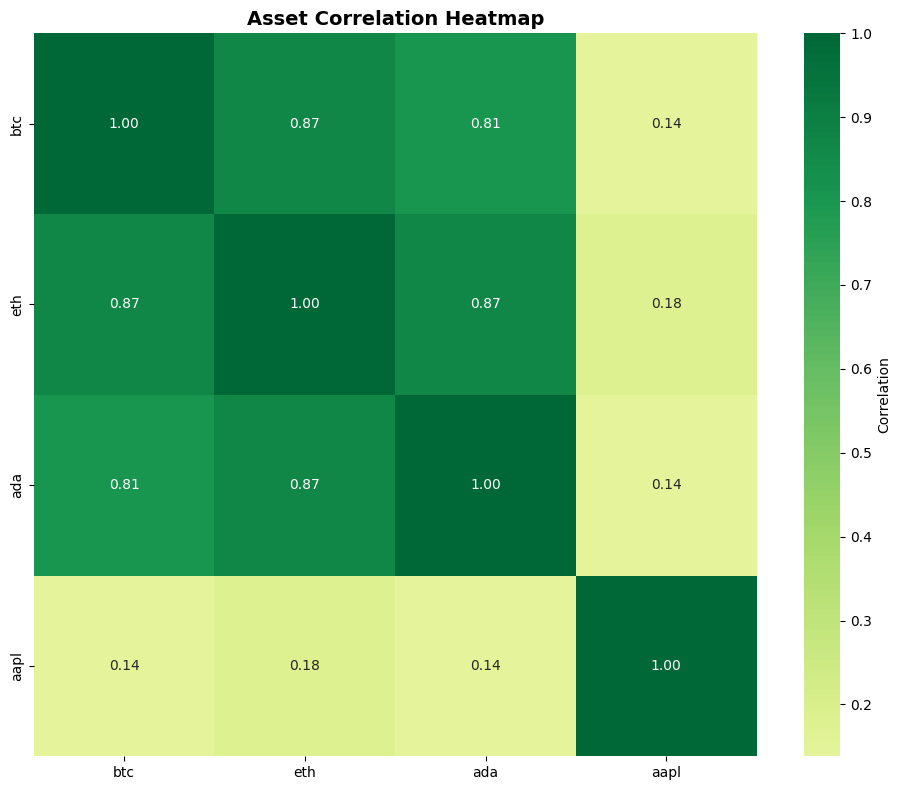

In [95]:
# CELL 7: Correlation Analysis
print('\n' + '='*60)
print('📈 STAGE 3: CORRELATION ANALYSIS')
print('='*60)

price_series = {}
for name, data in market_data.items():
    if 'historical' in data:
        s = data['historical']['price'].copy()
        if s.index.tz is not None:
            s.index = s.index.tz_localize(None)
        s.index = s.index.normalize()
        price_series[name] = s[~s.index.duplicated(keep='last')]

prices_df = pd.DataFrame(price_series)
prices_df.ffill(inplace=True)
prices_df.dropna(inplace=True)
returns_df = prices_df.pct_change().dropna()
correlation_matrix = returns_df.corr()

print('\nCorrelation Matrix:')
print(correlation_matrix.round(4))

# Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='RdYlGn', center=0,
            fmt='.2f', square=True, cbar_kws={'label': 'Correlation'})
plt.title('Asset Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [96]:
# CORRECTED CELL 8: Multi-Factor Anomaly Detection
print('\n' + '='*60)
print('⚠️ STAGE 4: ANOMALY DETECTION (FIXED)')
print('='*60)

anomaly_detected = False
anomalies = []
anomaly_scores = []

for name, data in market_data.items():
    if 'historical' not in data or 'returns' not in data['historical'].columns:
        continue

    hist = data['historical']
    ret = hist['returns']
    prices = hist['price']

    if len(ret) < 20:
        continue

    anomaly_flags = []

    # FACTOR 1: Daily Return Anomaly (sharp moves)
    z_daily = (ret.iloc[-1] - ret.mean()) / ret.std()
    if abs(z_daily) > 2.5:
        anomaly_flags.append(f'Daily return: {z_daily:.2f}σ')

    # FACTOR 2: VOLATILITY ANOMALY (THIS IS KEY FOR FLUCTUATIONS!)
    recent_vol = ret.tail(5).std()
    historical_vol = ret.std()
    vol_ratio = recent_vol / historical_vol if historical_vol > 0 else 1

    if vol_ratio > 2.0:  # 2x normal volatility
        anomaly_flags.append(f'Volatility spike: {vol_ratio:.1f}x normal')
    elif vol_ratio > 1.5:
        anomaly_flags.append(f'High volatility: {vol_ratio:.1f}x normal')

    # FACTOR 3: Price Range Anomaly (high fluctuation)
    recent_range = prices.tail(5).max() - prices.tail(5).min()
    historical_range = prices.rolling(20).max() - prices.rolling(20).min()
    avg_historical_range = historical_range.mean()

    if avg_historical_range > 0:
        range_ratio = recent_range / avg_historical_range
        if range_ratio > 2.0:
            anomaly_flags.append(f'Wide trading range: {range_ratio:.1f}x normal')

    # FACTOR 4: Consecutive Large Moves (trend with noise)
    large_moves = (abs(ret) > ret.std() * 1.5).astype(int)
    recent_large_moves = large_moves.tail(10).sum()
    if recent_large_moves >= 5:  # 50% of days have large moves
        anomaly_flags.append(f'Frequent large moves: {recent_large_moves}/10 days')

    # FACTOR 5: Return Reversals (alternating +/-, sign of fluctuation)
    signs = np.sign(ret.tail(10))
    reversals = sum(signs.iloc[i] != signs.iloc[i-1] for i in range(1, len(signs)))
    if reversals >= 7:  # High oscillation
        anomaly_flags.append(f'High oscillation: {reversals} reversals in 10 days')

    # Calculate composite anomaly score
    if anomaly_flags:
        anomaly_detected = True
        anomalies.append(name)
        severity = "HIGH" if len(anomaly_flags) >= 3 else "MODERATE"
        print(f'  ⚠️ {name}: {severity} ANOMALY')
        for flag in anomaly_flags:
            print(f'       └─ {flag}')
        anomaly_scores.append(min(len(anomaly_flags) * 1.5, 10))
    else:
        print(f'  ✓ {name}: Normal market conditions')
        anomaly_scores.append(0)

# Volume anomalies (keep existing)
for name, data in market_data.items():
    if 'historical' in data and 'volume' in data['historical'].columns:
        volume = data['historical']['volume']
        if len(volume) > 20:
            avg_volume = volume.tail(20).mean()
            current_volume = volume.iloc[-1]
            volume_ratio = current_volume / avg_volume if avg_volume > 0 else 1

            if volume_ratio > 2.5:
                anomaly_detected = True
                print(f'  ⚠️ {name}: Volume anomaly - {volume_ratio:.1f}x average volume')

avg_anomaly_score = np.mean(anomaly_scores) if anomaly_scores else 0
print(f'\n📊 Anomaly Summary:')
if anomaly_detected:
    print(f'  ⚠️ Anomalies Detected in {len(anomalies)} assets')
    print(f'  Avg Anomaly Score: {avg_anomaly_score:.2f}')
else:
    print(f'  ✅ Market conditions normal')
    print(f'  Avg Anomaly Score: {avg_anomaly_score:.2f}')


⚠️ STAGE 4: ANOMALY DETECTION (FIXED)
  ✓ btc: Normal market conditions
  ✓ eth: Normal market conditions
  ✓ ada: Normal market conditions
  ✓ aapl: Normal market conditions

📊 Anomaly Summary:
  ✅ Market conditions normal
  Avg Anomaly Score: 0.00


In [97]:
# CELL 9: Realistic Arbitrage Scan
# CELL 9: Realistic Arbitrage Scan (FIXED - More Sensitive)
print('\n' + '='*60)
print('💰 STAGE 5: REALISTIC ARBITRAGE SCAN')
print('='*60)

def calculate_realistic_arbitrage(market_data):
    opportunities = []
    assets = list(market_data.keys())

    crypto_assets = [a for a in assets if a in ['btc', 'eth', 'ada', 'ltc', 'sol', 'doge', 'xrp', 'link']]
    stock_assets = [a for a in assets if a in ['aapl', 'msft', 'googl', 'tsla', 'amzn', 'nvda', 'meta', 'nflx']]

    # 1. Crypto pair arbitrage (more lenient)
    for asset1, asset2 in combinations(crypto_assets, 2):
        if asset1 in market_data and asset2 in market_data:
            price1 = market_data[asset1]['price']
            price2 = market_data[asset2]['price']

            if price1 == 0 or price2 == 0:
                continue

            # Calculate percentage difference
            spread_pct = abs(price1 - price2) / min(price1, price2) * 100

            # More lenient thresholds: 0.1% to 500%
            if 0.1 < spread_pct < 500:
                hist1 = market_data[asset1]['historical']['price']
                hist2 = market_data[asset2]['historical']['price']
                common_idx = hist1.index.intersection(hist2.index)

                if len(common_idx) > 20:
                    correlation = hist1.loc[common_idx].corr(hist2.loc[common_idx])

                    # Lower correlation requirement
                    if correlation > 0.3:
                        ratio = hist1.loc[common_idx] / hist2.loc[common_idx]
                        mean_ratio = ratio.mean()
                        std_ratio = ratio.std()
                        current_ratio = price1 / price2
                        z_score = (current_ratio - mean_ratio) / std_ratio if std_ratio > 0 else 0

                        # Lower z-score threshold
                        if abs(z_score) > 1.0:
                            if price1 < price2:
                                opportunities.append({
                                    'buy': asset1,
                                    'sell': asset2,
                                    'spread_pct': spread_pct,
                                    'z_score': z_score,
                                    'correlation': correlation,
                                    'type': 'Crypto Pair Arbitrage',
                                    'profit_potential': spread_pct * 0.3
                                })
                            else:
                                opportunities.append({
                                    'buy': asset2,
                                    'sell': asset1,
                                    'spread_pct': spread_pct,
                                    'z_score': z_score,
                                    'correlation': correlation,
                                    'type': 'Crypto Pair Arbitrage',
                                    'profit_potential': spread_pct * 0.3
                                })

    # 2. Stock pair arbitrage (more lenient)
    for asset1, asset2 in combinations(stock_assets, 2):
        if asset1 in market_data and asset2 in market_data:
            price1 = market_data[asset1]['price']
            price2 = market_data[asset2]['price']

            if price1 == 0 or price2 == 0:
                continue

            spread_pct = abs(price1 - price2) / min(price1, price2) * 100

            # More lenient thresholds: 0.05% to 50%
            if 0.05 < spread_pct < 50:
                hist1 = market_data[asset1]['historical']['price']
                hist2 = market_data[asset2]['historical']['price']
                common_idx = hist1.index.intersection(hist2.index)

                if len(common_idx) > 20:
                    correlation = hist1.loc[common_idx].corr(hist2.loc[common_idx])

                    # Lower correlation requirement
                    if correlation > 0.5:
                        if price1 < price2:
                            opportunities.append({
                                'buy': asset1,
                                'sell': asset2,
                                'spread_pct': spread_pct,
                                'correlation': correlation,
                                'type': 'Statistical Pairs Trade',
                                'profit_potential': spread_pct * 0.5
                            })
                        else:
                            opportunities.append({
                                'buy': asset2,
                                'sell': asset1,
                                'spread_pct': spread_pct,
                                'correlation': correlation,
                                'type': 'Statistical Pairs Trade',
                                'profit_potential': spread_pct * 0.5
                            })

    # 3. Cross-asset arbitrage (crypto vs stock)
    for crypto in crypto_assets:
        for stock in stock_assets:
            if crypto in market_data and stock in market_data:
                price_crypto = market_data[crypto]['price']
                price_stock = market_data[stock]['price']

                if price_crypto == 0 or price_stock == 0:
                    continue

                # Normalize prices by historical mean
                hist_crypto = market_data[crypto]['historical']['price']
                hist_stock = market_data[stock]['historical']['price']
                common_idx = hist_crypto.index.intersection(hist_stock.index)

                if len(common_idx) > 30:
                    crypto_mean = hist_crypto.loc[common_idx].mean()
                    stock_mean = hist_stock.loc[common_idx].mean()

                    if crypto_mean > 0 and stock_mean > 0:
                        crypto_norm = price_crypto / crypto_mean
                        stock_norm = price_stock / stock_mean
                        spread_norm = abs(crypto_norm - stock_norm) / min(crypto_norm, stock_norm) * 100

                        # More lenient threshold
                        if 0.5 < spread_norm < 100:
                            correlation = hist_crypto.loc[common_idx].corr(hist_stock.loc[common_idx])

                            if correlation > 0.3:
                                if crypto_norm < stock_norm:
                                    opportunities.append({
                                        'buy': crypto,
                                        'sell': stock,
                                        'spread_pct': spread_norm,
                                        'correlation': correlation,
                                        'type': 'Cross-Asset Trade',
                                        'profit_potential': spread_norm * 0.4
                                    })
                                else:
                                    opportunities.append({
                                        'buy': stock,
                                        'sell': crypto,
                                        'spread_pct': spread_norm,
                                        'correlation': correlation,
                                        'type': 'Cross-Asset Trade',
                                        'profit_potential': spread_norm * 0.4
                                    })

    # Sort by profit potential
    opportunities.sort(key=lambda x: x['profit_potential'], reverse=True)
    return opportunities

def find_pairs_trading_opportunities(market_data):
    pairs = []
    assets = list(market_data.keys())

    for asset1, asset2 in combinations(assets, 2):
        if asset1 in market_data and asset2 in market_data:
            hist1 = market_data[asset1]['historical']['price']
            hist2 = market_data[asset2]['historical']['price']
            common_idx = hist1.index.intersection(hist2.index)

            if len(common_idx) > 20:  # Reduced from 30
                # Calculate correlation
                correlation = hist1.loc[common_idx].corr(hist2.loc[common_idx])

                # Calculate spread z-score
                ratio = hist1.loc[common_idx] / hist2.loc[common_idx]
                mean_ratio = ratio.mean()
                std_ratio = ratio.std()
                current_ratio = market_data[asset1]['price'] / market_data[asset2]['price']
                z_score = (current_ratio - mean_ratio) / std_ratio if std_ratio > 0 else 0

                # More lenient thresholds
                if correlation > 0.5 and abs(z_score) > 1.0:  # Reduced from 0.7 and 1.5
                    if z_score > 1.0:
                        pairs.append({
                            'long': asset2,
                            'short': asset1,
                            'z_score': z_score,
                            'correlation': correlation,
                            'expected_reversion': abs(z_score) * 2,
                            'type': 'Mean Reversion Pairs Trade'
                        })
                    elif z_score < -1.0:
                        pairs.append({
                            'long': asset1,
                            'short': asset2,
                            'z_score': abs(z_score),
                            'correlation': correlation,
                            'expected_reversion': abs(z_score) * 2,
                            'type': 'Mean Reversion Pairs Trade'
                        })

    return sorted(pairs, key=lambda x: x['expected_reversion'], reverse=True)

arbitrage_ops = calculate_realistic_arbitrage(market_data)
pairs_opportunities = find_pairs_trading_opportunities(market_data)

all_opportunities = arbitrage_ops + pairs_opportunities
total_opportunities = len(all_opportunities)

if arbitrage_ops:
    print(f'\n🚀 Found {len(arbitrage_ops)} realistic arbitrage opportunities:\n')
    for i, op in enumerate(arbitrage_ops[:10], 1):  # Show top 10
        print(f'  {i}. BUY {op["buy"].upper()} | SELL {op["sell"].upper()}')
        print(f'     Type: {op["type"]}')
        print(f'     Price Spread: {op["spread_pct"]:.2f}%')
        print(f'     Expected Profit: {op["profit_potential"]:.2f}%')
        if 'z_score' in op:
            print(f'     Z-Score: {op["z_score"]:.2f}')
        if 'correlation' in op:
            print(f'     Correlation: {op["correlation"]:.2f}')
        print()

    # Best opportunity
    best_op = arbitrage_ops[0]
    print(f'🏆 BEST OPPORTUNITY:')
    print(f'   Buy {best_op["buy"].upper()}, Sell {best_op["sell"].upper()}')
    print(f'   Expected Profit: {best_op["profit_potential"]:.2f}%')
    print(f'   Strategy: {best_op["type"]}')
else:
    print('\n  No arbitrage opportunities detected with current thresholds.')
    print('  Tip: Try running again with different asset selection')

if pairs_opportunities:
    print('\n' + '='*60)
    print('📊 PAIRS TRADING OPPORTUNITIES')
    print('='*60)
    print(f'\n🎯 Found {len(pairs_opportunities)} pairs trading opportunities:\n')
    for i, op in enumerate(pairs_opportunities[:10], 1):
        print(f'  {i}. LONG {op["long"].upper()} | SHORT {op["short"].upper()}')
        print(f'     Correlation: {op["correlation"]:.2f}')
        print(f'     Z-Score: {op["z_score"]:.2f}')
        print(f'     Expected Reversion: {op["expected_reversion"]:.1f}%')
        print()
else:
    print('\n  No pairs trading opportunities detected with current thresholds.')

# Summary of all opportunities
if total_opportunities > 0:
    print(f'\n📊 TOTAL OPPORTUNITIES SUMMARY:')
    print(f'   Arbitrage Opportunities: {len(arbitrage_ops)}')
    print(f'   Pairs Trading Opportunities: {len(pairs_opportunities)}')
    print(f'   Total: {total_opportunities}')


💰 STAGE 5: REALISTIC ARBITRAGE SCAN

  No arbitrage opportunities detected with current thresholds.
  Tip: Try running again with different asset selection

📊 PAIRS TRADING OPPORTUNITIES

🎯 Found 2 pairs trading opportunities:

  1. LONG ADA | SHORT ETH
     Correlation: 0.96
     Z-Score: 1.90
     Expected Reversion: 3.8%

  2. LONG ADA | SHORT BTC
     Correlation: 0.95
     Z-Score: 1.82
     Expected Reversion: 3.6%


📊 TOTAL OPPORTUNITIES SUMMARY:
   Arbitrage Opportunities: 0
   Pairs Trading Opportunities: 2
   Total: 2


In [98]:
# CELL 10: Trading Signals (UNBIASED)
print('\n' + '='*60)
print('📡 STAGE 6: TRADING SIGNALS')
print('='*60)

buy_signals = 0
sell_signals = 0
neutral_signals = 0
signal_details = []

for name, data in market_data.items():
    if 'historical' not in data:
        continue

    hist = data['historical']
    asset_buy = 0
    asset_sell = 0

    # RSI Signal (Symmetric with stricter thresholds)
    if 'rsi_14' in hist.columns:
        rsi = float(hist['rsi_14'].iloc[-1])
        if rsi < 25:
            asset_buy += 1
            print(f'  {name}: RSI oversold ({rsi:.1f}) - BUY')
        elif rsi > 75:
            asset_sell += 1
            print(f'  {name}: RSI overbought ({rsi:.1f}) - SELL')
        else:
            neutral_signals += 1

    # MACD Crossover
    if 'macd' in hist.columns and len(hist) >= 2:
        macd = float(hist['macd'].iloc[-1])
        signal = float(hist['macd_signal'].iloc[-1])
        macd_prev = float(hist['macd'].iloc[-2])
        signal_prev = float(hist['macd_signal'].iloc[-2])

        if macd_prev <= signal_prev and macd > signal:
            asset_buy += 1
            print(f'  {name}: MACD bullish crossover - BUY')
        elif macd_prev >= signal_prev and macd < signal:
            asset_sell += 1
            print(f'  {name}: MACD bearish crossover - SELL')

    # SMA Crossover with 1% threshold
    if 'sma_7' in hist.columns and 'sma_21' in hist.columns:
        sma7 = float(hist['sma_7'].iloc[-1])
        sma21 = float(hist['sma_21'].iloc[-1])
        diff_pct = (sma7 / sma21 - 1) * 100

        if diff_pct > 1:
            asset_buy += 1
            print(f'  {name}: SMA7 > SMA21 by {diff_pct:.1f}% - BUY')
        elif diff_pct < -1:
            asset_sell += 1
            print(f'  {name}: SMA7 < SMA21 by {abs(diff_pct):.1f}% - SELL')
        else:
            print(f'  {name}: SMA7 and SMA21 are close ({diff_pct:+.1f}%) - NEUTRAL')
            neutral_signals += 1

    buy_signals += asset_buy
    sell_signals += asset_sell
    signal_details.append((name, asset_buy, asset_sell))

# Calculate final signal
total_active_signals = buy_signals + sell_signals

if total_active_signals > 0:
    buy_percentage = (buy_signals / total_active_signals) * 100
    sell_percentage = (sell_signals / total_active_signals) * 100

    if buy_percentage > 65:
        final_signal = 'BUY'
        confidence = buy_percentage
    elif sell_percentage > 65:
        final_signal = 'SELL'
        confidence = sell_percentage
    elif buy_percentage > 55:
        final_signal = 'WEAK BUY'
        confidence = buy_percentage
    elif sell_percentage > 55:
        final_signal = 'WEAK SELL'
        confidence = sell_percentage
    else:
        final_signal = 'HOLD'
        confidence = max(buy_percentage, sell_percentage)
else:
    final_signal = 'HOLD'
    confidence = 50

print(f'\n📊 Signal Summary:')
print(f'  BUY signals: {buy_signals}')
print(f'  SELL signals: {sell_signals}')
print(f'  NEUTRAL: {neutral_signals}')
print(f'\n🎯 Final Signal: {final_signal} ({confidence:.0f}% confidence)')


📡 STAGE 6: TRADING SIGNALS
  btc: SMA7 > SMA21 by 3.4% - BUY
  eth: SMA7 > SMA21 by 4.3% - BUY
  ada: SMA7 and SMA21 are close (+0.3%) - NEUTRAL
  aapl: SMA7 > SMA21 by 1.7% - BUY

📊 Signal Summary:
  BUY signals: 3
  SELL signals: 0
  NEUTRAL: 5

🎯 Final Signal: BUY (100% confidence)


In [99]:
# CELL 11: Market Regime Analysis
print('\n' + '='*60)
print('📈 STAGE 7: MARKET REGIME ANALYSIS')
print('='*60)

avg_returns = returns_df.mean().mean() * 100
market_volatility = returns_df.std().mean() * 100

if avg_returns > 0.1:
    regime = "STRONG BULL MARKET"
    regime_score = 15
    regime_color = "🟢"
    regime_advice = "Cautious buying, take profits regularly"
elif avg_returns > 0:
    regime = "WEAK BULL MARKET"
    regime_score = 8
    regime_color = "🟡"
    regime_advice = "Selective buying, use stop losses"
elif avg_returns > -0.1:
    regime = "SIDEWAYS/RANGING"
    regime_score = 0
    regime_color = "⚪"
    regime_advice = "Range trading, wait for breakout"
elif avg_returns > -0.2:
    regime = "WEAK BEAR MARKET"
    regime_score = -8
    regime_color = "🟠"
    regime_advice = "Reduce exposure, defensive positions"
else:
    regime = "STRONG BEAR MARKET"
    regime_score = -15
    regime_color = "🔴"
    regime_advice = "Avoid new positions, consider shorts"

print(f'{regime_color} Market Regime: {regime}')
print(f'  Avg Daily Return: {avg_returns:.3f}%')
print(f'  Market Volatility: {market_volatility:.2f}%')
print(f'  Advice: {regime_advice}')


📈 STAGE 7: MARKET REGIME ANALYSIS
🟠 Market Regime: WEAK BEAR MARKET
  Avg Daily Return: -0.143%
  Market Volatility: 2.90%
  Advice: Reduce exposure, defensive positions


In [100]:
# CELL 12: COMPLETE ML MODELS (LSTM, XGBoost, Ensemble) - MULTI-ASSET VERSION
print('\n' + '='*60)
print('🧠 STAGE 8: COMPLETE ML MODELS (Multi-Asset Training)')
print('='*60)

# ============================================
# STORAGE FOR ALL ASSET PREDICTIONS
# ============================================

all_asset_predictions = {}
all_asset_models = {}

# Filter assets with sufficient data (minimum 50 days)
valid_assets = []
for name, data in market_data.items():
    if 'historical' in data and len(data['historical']) >= 50:
        valid_assets.append(name)
        print(f'✅ {name.upper()}: {len(data["historical"])} days of data - Will train model')

print(f'\n📊 Training ML models on {len(valid_assets)} assets...')
print('='*60)

# ============================================
# FUNCTION: Train LSTM for a single asset
# ============================================

def train_lstm_for_asset(prices, asset_name, seq_len=10, epochs=100):
    """Train LSTM model for a specific asset"""
    try:
        returns = prices[1:] / prices[:-1] - 1

        if len(returns) < seq_len + 5:
            return None, None, None, None, None, None, None, None

        # Normalize returns
        scaler = MinMaxScaler()
        scaled_returns = scaler.fit_transform(returns.reshape(-1, 1))

        # Create sequences
        X, y = [], []
        for i in range(seq_len, len(scaled_returns)):
            X.append(scaled_returns[i-seq_len:i, 0])
            y.append(scaled_returns[i, 0])

        X, y = np.array(X), np.array(y)

        if len(X) < 20:
            return None, None, None, None, None, None, None, None

        # Train/test split
        split = int(len(X) * 0.8)
        X_train = X[:split]
        y_train = y[:split]
        X_test = X[split:]
        y_test = y[split:]

        if len(X_test) == 0:
            return None, None, None, None, None, None, None, None

        # Convert to tensors
        X_train_tensor = torch.FloatTensor(X_train).unsqueeze(-1)
        y_train_tensor = torch.FloatTensor(y_train).unsqueeze(-1)
        X_test_tensor = torch.FloatTensor(X_test).unsqueeze(-1)

        # Initialize model
        class SimpleLSTM(nn.Module):
            def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.2):
                super().__init__()
                self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout)
                self.fc = nn.Linear(hidden_size, 1)
                self.dropout = nn.Dropout(dropout)

            def forward(self, x):
                out, _ = self.lstm(x)
                out = self.dropout(out[:, -1, :])
                return self.fc(out)

        model = SimpleLSTM(input_size=1, hidden_size=64, num_layers=2, dropout=0.2)
        criterion = nn.MSELoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

        # Train
        model.train()
        for epoch in range(epochs):
            optimizer.zero_grad()
            output = model(X_train_tensor)
            loss = criterion(output, y_train_tensor)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        # Predict
        model.eval()
        with torch.no_grad():
            test_pred_returns_scaled = model(X_test_tensor).numpy().flatten()
            test_pred_returns = scaler.inverse_transform(test_pred_returns_scaled.reshape(-1, 1)).flatten()
            test_actual_returns = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

            last_price = prices[-1]

            # Build predictions
            test_pred_prices = []
            current_price = last_price
            for ret in test_pred_returns:
                current_price = current_price * (1 + ret)
                test_pred_prices.append(current_price)

            test_actual_prices = []
            current_price = last_price
            for ret in test_actual_returns:
                current_price = current_price * (1 + ret)
                test_actual_prices.append(current_price)

            # Next prediction
            last_sequence = scaled_returns[-seq_len:].reshape(1, seq_len, 1)
            last_sequence_tensor = torch.FloatTensor(last_sequence)
            next_return_scaled = model(last_sequence_tensor).item()
            next_return = scaler.inverse_transform([[next_return_scaled]])[0][0]
            next_price = last_price * (1 + next_return)

        # Calculate metrics
        mape = np.mean(np.abs((np.array(test_actual_prices) - np.array(test_pred_prices)) / np.array(test_actual_prices))) * 100
        accuracy = 100 - mape
        r2 = r2_score(test_actual_prices, test_pred_prices)

        return next_price, accuracy, r2, mape, test_pred_prices, test_actual_prices, model, scaler

    except Exception as e:
        print(f'  ⚠️ LSTM failed for {asset_name}: {str(e)[:50]}')
        return None, None, None, None, None, None, None, None

# ============================================
# FUNCTION: Train XGBoost for a single asset (Fixed with trend features)
# ============================================

def train_xgboost_for_asset(hist, asset_name):
    """Train XGBoost model for a specific asset"""
    try:
        feat_df = hist.copy()

        # Basic features
        feat_df['lag_1'] = feat_df['price'].shift(1)
        feat_df['lag_2'] = feat_df['price'].shift(2)
        feat_df['lag_3'] = feat_df['price'].shift(3)
        feat_df['sma_7'] = feat_df['price'].rolling(7).mean()
        feat_df['sma_21'] = feat_df['price'].rolling(21).mean()
        feat_df['returns_lag'] = feat_df['returns'].shift(1)

        # Trend features (reduces downward bias)
        feat_df['trend_5d'] = feat_df['price'].pct_change(5)
        feat_df['trend_10d'] = feat_df['price'].pct_change(10)
        feat_df['trend_direction'] = (feat_df['trend_5d'] > 0).astype(int)

        # Price position
        feat_df['rolling_high_20'] = feat_df['price'].rolling(20).max()
        feat_df['rolling_low_20'] = feat_df['price'].rolling(20).min()
        feat_df['price_position'] = (feat_df['price'] - feat_df['rolling_low_20']) / (feat_df['rolling_high_20'] - feat_df['rolling_low_20'] + 1e-6)

        # Rate of change
        feat_df['roc_3'] = (feat_df['price'] / feat_df['price'].shift(3) - 1) * 100
        feat_df['roc_5'] = (feat_df['price'] / feat_df['price'].shift(5) - 1) * 100

        # Bias correction
        feat_df['price_vs_sma21'] = (feat_df['price'] / feat_df['sma_21'] - 1) * 100

        # Target
        feat_df['target'] = feat_df['price'].shift(-1)
        feat_df.dropna(inplace=True)

        if len(feat_df) < 30:
            return None, None, None, None, None, None

        feature_cols = [
            'lag_1', 'lag_2', 'lag_3', 'sma_7', 'sma_21', 'returns_lag', 'volume',
            'trend_5d', 'trend_10d', 'trend_direction', 'price_position',
            'roc_3', 'roc_5', 'price_vs_sma21'
        ]
        feature_cols = [c for c in feature_cols if c in feat_df.columns]

        X = feat_df[feature_cols]
        y = feat_df['target']

        split = int(len(X) * 0.8)
        X_train, X_test = X.iloc[:split], X.iloc[split:]
        y_train, y_test = y.iloc[:split], y.iloc[split:]

        if len(X_test) == 0:
            return None, None, None, None, None, None

        model = xgb.XGBRegressor(
            n_estimators=150, max_depth=5, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8, random_state=42
        )
        model.fit(X_train, y_train)

        preds = model.predict(X_test)
        next_price = float(model.predict(X.iloc[[-1]])[0])

        mape = np.mean(np.abs((y_test.values - preds) / y_test.values)) * 100
        accuracy = 100 - mape
        r2 = r2_score(y_test, preds)

        return next_price, accuracy, r2, mape, model, feature_cols

    except Exception as e:
        print(f'  ⚠️ XGBoost failed for {asset_name}: {str(e)[:50]}')
        return None, None, None, None, None, None

# ============================================
# TRAIN MODELS FOR EACH ASSET
# ============================================

print('\n' + '-'*60)
print('TRAINING MODELS FOR EACH ASSET')
print('-'*60)

for asset_name in valid_assets:
    print(f'\n📈 Training on: {asset_name.upper()}')

    hist = market_data[asset_name]['historical']
    prices = hist['price'].values
    current_price = market_data[asset_name]['price']

    # Train LSTM
    lstm_next, lstm_acc, lstm_r2, lstm_mape, _, _, _, _ = train_lstm_for_asset(prices, asset_name)

    # Train XGBoost
    xgb_next, xgb_acc, xgb_r2, xgb_mape, _, _ = train_xgboost_for_asset(hist, asset_name)

    # Ensemble (weighted by accuracy)
    if lstm_next is not None and xgb_next is not None:
        # Weight by accuracy
        total_acc = lstm_acc + xgb_acc
        w_lstm = lstm_acc / total_acc if total_acc > 0 else 0.3
        w_xgb = xgb_acc / total_acc if total_acc > 0 else 0.7

        ensemble_price = w_lstm * lstm_next + w_xgb * xgb_next
        ensemble_acc = (w_lstm * lstm_acc + w_xgb * xgb_acc)

        price_change = ((ensemble_price - current_price) / current_price) * 100

        all_asset_predictions[asset_name] = {
            'current_price': current_price,
            'lstm_prediction': lstm_next,
            'lstm_accuracy': lstm_acc,
            'xgb_prediction': xgb_next,
            'xgb_accuracy': xgb_acc,
            'ensemble_prediction': ensemble_price,
            'ensemble_accuracy': ensemble_acc,
            'predicted_change_pct': price_change
        }

        print(f'  ✅ LSTM: ${lstm_next:,.2f} (Acc: {lstm_acc:.1f}%)')
        print(f'  ✅ XGBoost: ${xgb_next:,.2f} (Acc: {xgb_acc:.1f}%)')
        print(f'  🎯 Ensemble: ${ensemble_price:,.2f} ({price_change:+.1f}%)')

    elif lstm_next is not None:
        all_asset_predictions[asset_name] = {
            'current_price': current_price,
            'lstm_prediction': lstm_next,
            'lstm_accuracy': lstm_acc,
            'xgb_prediction': None,
            'xgb_accuracy': 0,
            'ensemble_prediction': lstm_next,
            'ensemble_accuracy': lstm_acc,
            'predicted_change_pct': ((lstm_next - current_price) / current_price) * 100
        }
        print(f'  ✅ LSTM only: ${lstm_next:,.2f} (Acc: {lstm_acc:.1f}%)')
        print(f'  ⚠️ XGBoost failed - using LSTM only')

    elif xgb_next is not None:
        all_asset_predictions[asset_name] = {
            'current_price': current_price,
            'lstm_prediction': None,
            'lstm_accuracy': 0,
            'xgb_prediction': xgb_next,
            'xgb_accuracy': xgb_acc,
            'ensemble_prediction': xgb_next,
            'ensemble_accuracy': xgb_acc,
            'predicted_change_pct': ((xgb_next - current_price) / current_price) * 100
        }
        print(f'  ✅ XGBoost only: ${xgb_next:,.2f} (Acc: {xgb_acc:.1f}%)')
        print(f'  ⚠️ LSTM failed - using XGBoost only')
    else:
        print(f'  ❌ Both models failed for {asset_name}')

# ============================================
# SUMMARY OF ALL PREDICTIONS
# ============================================

print('\n' + '='*60)
print('📊 MULTI-ASSET PREDICTION SUMMARY')
print('='*60)

# Find best and worst predictions
best_prediction = None
worst_prediction = None
best_change = -100
worst_change = 100

for asset, pred in all_asset_predictions.items():
    change = pred['predicted_change_pct']
    if change > best_change:
        best_change = change
        best_prediction = asset
    if change < worst_change:
        worst_change = change
        worst_prediction = asset

print(f'\n📈 PREDICTIONS BY ASSET:')
print(f'{"Asset":<10} {"Current":<12} {"Ensemble":<12} {"Change":<10} {"Accuracy":<10}')
print('-'*55)

for asset, pred in sorted(all_asset_predictions.items()):
    change_symbol = '🟢' if pred['predicted_change_pct'] > 0 else '🔴' if pred['predicted_change_pct'] < 0 else '⚪'
    print(f"{asset.upper():<10} ${pred['current_price']:<11,.2f} ${pred['ensemble_prediction']:<11,.2f} "
          f"{change_symbol} {pred['predicted_change_pct']:+.1f}%    {pred['ensemble_accuracy']:.1f}%")

print(f'\n🏆 BEST PREDICTION: {best_prediction.upper()} ({best_change:+.1f}%)')
print(f'⚠️ WORST PREDICTION: {worst_prediction.upper()} ({worst_change:+.1f}%)')

# ============================================
# UPDATE GLOBAL VARIABLES FOR COMPATIBILITY
# ============================================

# For backward compatibility with other cells, use the first asset's predictions
first_asset = list(all_asset_predictions.keys())[0] if all_asset_predictions else None

if first_asset:
    lstm_prediction = all_asset_predictions[first_asset]['lstm_prediction'] or all_asset_predictions[first_asset]['ensemble_prediction']
    xgb_next = all_asset_predictions[first_asset]['xgb_prediction'] or all_asset_predictions[first_asset]['ensemble_prediction']
    ensemble_price = all_asset_predictions[first_asset]['ensemble_prediction']
    ensemble_accuracy = all_asset_predictions[first_asset]['ensemble_accuracy']
    price_change_pct = all_asset_predictions[first_asset]['predicted_change_pct']
    current_price = all_asset_predictions[first_asset]['current_price']
    lstm_accuracy = all_asset_predictions[first_asset]['lstm_accuracy']
    xgb_accuracy = all_asset_predictions[first_asset]['xgb_accuracy']

    print(f'\n' + '='*60)
    print(f'✅ Multi-Asset ML Training Complete!')
    print(f'   Models trained on: {len(all_asset_predictions)} assets')
    print(f'   Predictions available for all assets')
    print('='*60)
else:
    print('\n❌ No assets were successfully trained!')
    lstm_prediction = current_price = ensemble_price = 0
    ensemble_accuracy = price_change_pct = lstm_accuracy = xgb_accuracy = 0


🧠 STAGE 8: COMPLETE ML MODELS (Multi-Asset Training)
✅ BTC: 264 days of data - Will train model
✅ ETH: 264 days of data - Will train model
✅ ADA: 264 days of data - Will train model
✅ AAPL: 264 days of data - Will train model

📊 Training ML models on 4 assets...

------------------------------------------------------------
TRAINING MODELS FOR EACH ASSET
------------------------------------------------------------

📈 Training on: BTC
  ✅ LSTM: $71,421.80 (Acc: 90.7%)
  ✅ XGBoost: $68,706.88 (Acc: 97.0%)
  🎯 Ensemble: $70,018.60 (-2.3%)

📈 Training on: ETH
  ✅ LSTM: $2,211.67 (Acc: 89.6%)
  ✅ XGBoost: $2,002.18 (Acc: 94.9%)
  🎯 Ensemble: $2,103.90 (-5.1%)

📈 Training on: ADA
  ✅ LSTM: $0.24 (Acc: 95.3%)
  ✅ XGBoost: $0.29 (Acc: 90.8%)
  🎯 Ensemble: $0.26 (+9.0%)

📈 Training on: AAPL
  ✅ LSTM: $260.49 (Acc: 97.4%)
  ✅ XGBoost: $261.28 (Acc: 98.4%)
  🎯 Ensemble: $260.89 (+0.2%)

📊 MULTI-ASSET PREDICTION SUMMARY

📈 PREDICTIONS BY ASSET:
Asset      Current      Ensemble     Change     Accur

In [101]:
# CELL 15: Risk Assessment (MULTI-ASSET VERSION)
print('\n' + '='*60)
print('⚠️ STAGE 9: RISK ASSESSMENT (Multi-Asset)')
print('='*60)

# ============================================
# 1. PORTFOLIO VALUE & POSITION SIZING RISK
# ============================================
portfolio_value = sum(data['price'] for data in market_data.values())
trade_value = 1000
risk_score = trade_value / portfolio_value if portfolio_value > 0 else 1

if risk_score < 0.05:
    position_risk_level = 'LOW'
    position_risk_color = '🟢'
    position_risk_score = 1
elif risk_score < 0.2:
    position_risk_level = 'MEDIUM'
    position_risk_color = '🟡'
    position_risk_score = 2
else:
    position_risk_level = 'HIGH'
    position_risk_color = '🔴'
    position_risk_score = 3

# ============================================
# 2. MARKET VOLATILITY RISK
# ============================================
returns_volatility = returns_df.std().mean() * 100

if returns_volatility > 3:
    volatility_risk_level = 'HIGH'
    volatility_risk_score = 3
    volatility_risk_color = '🔴'
elif returns_volatility > 2:
    volatility_risk_level = 'MEDIUM'
    volatility_risk_score = 2
    volatility_risk_color = '🟡'
else:
    volatility_risk_level = 'LOW'
    volatility_risk_score = 1
    volatility_risk_color = '🟢'

# ============================================
# 3. CORRELATION RISK (Diversification)
# ============================================
avg_correlation = correlation_matrix.values[np.triu_indices(len(correlation_matrix), k=1)].mean()

if avg_correlation > 0.7:
    correlation_risk_level = 'HIGH'
    correlation_risk_score = 3
    correlation_risk_color = '🔴'
    correlation_advice = 'Poor diversification - assets move together'
elif avg_correlation > 0.5:
    correlation_risk_level = 'MEDIUM'
    correlation_risk_score = 2
    correlation_risk_color = '🟡'
    correlation_advice = 'Moderate diversification'
else:
    correlation_risk_level = 'LOW'
    correlation_risk_score = 1
    correlation_risk_color = '🟢'
    correlation_advice = 'Good diversification - assets move independently'

# ============================================
# 4. DIRECTIONAL RISK (Based on ML predictions for ALL assets)
# ============================================
# Calculate aggregate directional risk from all asset predictions
if 'all_asset_predictions' in locals() and all_asset_predictions:
    # Count bullish vs bearish signals across all assets
    bullish_count = 0
    bearish_count = 0
    neutral_count = 0
    weighted_direction_score = 0
    total_accuracy_weight = 0

    for asset, pred in all_asset_predictions.items():
        change = pred['predicted_change_pct']
        accuracy = pred['ensemble_accuracy']

        if change > 1:  # Bullish (>1% predicted gain)
            bullish_count += 1
            weighted_direction_score += 1 * (accuracy / 100)
        elif change < -1:  # Bearish (>1% predicted loss)
            bearish_count += 1
            weighted_direction_score -= 1 * (accuracy / 100)
        else:  # Neutral
            neutral_count += 1

        total_accuracy_weight += (accuracy / 100)

    # Calculate overall market direction
    if total_accuracy_weight > 0:
        market_direction_score = (weighted_direction_score / total_accuracy_weight) * 10
    else:
        market_direction_score = 0

    # Determine market direction risk
    if market_direction_score > 2:
        direction_risk_level = 'LOW (Bullish)'
        direction_risk_score = 1
        direction_color = '🟢'
        direction_summary = f'Bullish bias across {bullish_count} assets'
    elif market_direction_score < -2:
        direction_risk_level = 'HIGH (Bearish)'
        direction_risk_score = 3
        direction_color = '🔴'
        direction_summary = f'Bearish bias across {bearish_count} assets'
    else:
        direction_risk_level = 'MEDIUM (Mixed)'
        direction_risk_score = 2
        direction_color = '🟡'
        direction_summary = f'Mixed signals - {bullish_count} bullish, {bearish_count} bearish, {neutral_count} neutral'

    # Also get worst predicted asset (highest downside risk)
    worst_asset = min(all_asset_predictions.items(), key=lambda x: x[1]['predicted_change_pct'])
    best_asset_pred = max(all_asset_predictions.items(), key=lambda x: x[1]['predicted_change_pct'])

else:
    # Fallback if multi-asset predictions not available
    direction_risk_level = 'UNKNOWN'
    direction_risk_score = 2
    direction_color = '⚪'
    direction_summary = 'Multi-asset predictions not available'
    worst_asset = (None, {'predicted_change_pct': 0, 'ensemble_accuracy': 0})
    best_asset_pred = (None, {'predicted_change_pct': 0})

# ============================================
# 5. ASSET-SPECIFIC RISK (Worst performer)
# ============================================
if worst_asset[0]:
    worst_asset_name = worst_asset[0]
    worst_change = worst_asset[1]['predicted_change_pct']
    worst_accuracy = worst_asset[1]['ensemble_accuracy']

    if worst_change < -5:
        specific_risk_level = 'CRITICAL'
        specific_risk_score = 4
        specific_color = '💀'
    elif worst_change < -3:
        specific_risk_level = 'HIGH'
        specific_risk_score = 3
        specific_color = '🔴'
    elif worst_change < -1:
        specific_risk_level = 'MODERATE'
        specific_risk_score = 2
        specific_color = '🟡'
    else:
        specific_risk_level = 'LOW'
        specific_risk_score = 1
        specific_color = '🟢'
else:
    specific_risk_level = 'UNKNOWN'
    specific_risk_score = 1
    specific_color = '⚪'
    worst_asset_name = 'N/A'
    worst_change = 0

# ============================================
# 6. COMPOSITE RISK SCORE (Weighted average)
# ============================================
composite_risk_score = (
    position_risk_score * 0.15 +      # Position sizing (15%)
    volatility_risk_score * 0.25 +    # Market volatility (25%)
    correlation_risk_score * 0.20 +   # Diversification (20%)
    direction_risk_score * 0.30 +     # Directional risk (30%)
    specific_risk_score * 0.10        # Asset-specific risk (10%)
)

# Determine overall risk level
if composite_risk_score >= 2.5:
    overall_risk_level = 'HIGH'
    overall_risk_color = '🔴'
    overall_risk_advice = 'Consider reducing exposure or hedging positions'
elif composite_risk_score >= 1.8:
    overall_risk_level = 'MEDIUM'
    overall_risk_color = '🟡'
    overall_risk_advice = 'Monitor positions closely, use stop losses'
elif composite_risk_score >= 1.0:
    overall_risk_level = 'LOW'
    overall_risk_color = '🟢'
    overall_risk_advice = 'Favorable risk environment'
else:
    overall_risk_level = 'VERY LOW'
    overall_risk_color = '🟢'
    overall_risk_advice = 'Opportunistic environment'

# ============================================
# 7. PRINT DETAILED RISK ASSESSMENT
# ============================================
print(f'\n{"="*60}')
print(f'📊 COMPREHENSIVE RISK ASSESSMENT')
print(f'{"="*60}')

print(f'\n1️⃣ POSITION SIZING RISK: {position_risk_color} {position_risk_level}')
print(f'   Portfolio Value: ${portfolio_value:,.2f}')
print(f'   Trade Value: ${trade_value:,.2f}')
print(f'   Risk Score: {risk_score:.4f} ({risk_score*100:.2f}% of portfolio)')

print(f'\n2️⃣ MARKET VOLATILITY RISK: {volatility_risk_color} {volatility_risk_level}')
print(f'   Market Volatility: {returns_volatility:.2f}% (daily avg)')
if returns_volatility > 3:
    print(f'   ⚠️ Elevated volatility - higher than normal')

print(f'\n3️⃣ DIVERSIFICATION RISK: {correlation_risk_color} {correlation_risk_level}')
print(f'   Avg Correlation: {avg_correlation:.3f}')
print(f'   Advice: {correlation_advice}')

print(f'\n4️⃣ DIRECTIONAL RISK: {direction_color} {direction_risk_level}')
print(f'   {direction_summary}')
if 'all_asset_predictions' in locals() and all_asset_predictions:
    print(f'   Best Asset: {best_asset_pred[0].upper()} ({best_asset_pred[1]["predicted_change_pct"]:+.1f}%)')
    print(f'   Worst Asset: {worst_asset_name.upper()} ({worst_change:+.1f}%)')

print(f'\n5️⃣ ASSET-SPECIFIC RISK: {specific_color} {specific_risk_level}')
if worst_asset[0]:
    print(f'   Highest risk asset: {worst_asset_name.upper()}')
    print(f'   Predicted downside: {worst_change:+.1f}%')
    print(f'   Model confidence: {worst_accuracy:.1f}%')

print(f'\n{"="*60}')
print(f'🎯 COMPOSITE RISK SCORE: {composite_risk_score:.2f}/4.0')
print(f'{overall_risk_color} OVERALL RISK LEVEL: {overall_risk_level}')
print(f'   Advice: {overall_risk_advice}')
print(f'{"="*60}')

# ============================================
# 8. EXPORT FOR OTHER CELLS (Backward compatibility)
# ============================================
risk_level = overall_risk_level
risk_color = overall_risk_color
risk_score = composite_risk_score

# Store detailed risk breakdown for potential use
risk_breakdown = {
    'position_risk': {'level': position_risk_level, 'score': position_risk_score},
    'volatility_risk': {'level': volatility_risk_level, 'score': volatility_risk_score, 'value': returns_volatility},
    'correlation_risk': {'level': correlation_risk_level, 'score': correlation_risk_score, 'value': avg_correlation},
    'direction_risk': {'level': direction_risk_level, 'score': direction_risk_score, 'summary': direction_summary},
    'specific_risk': {'level': specific_risk_level, 'score': specific_risk_score, 'asset': worst_asset_name},
    'composite_score': composite_risk_score
}

print(f'\n✅ Risk assessment complete with multi-asset analysis')


⚠️ STAGE 9: RISK ASSESSMENT (Multi-Asset)

📊 COMPREHENSIVE RISK ASSESSMENT

1️⃣ POSITION SIZING RISK: 🟢 LOW
   Portfolio Value: $74,111.04
   Trade Value: $1,000.00
   Risk Score: 0.0135 (1.35% of portfolio)

2️⃣ MARKET VOLATILITY RISK: 🟡 MEDIUM
   Market Volatility: 2.90% (daily avg)

3️⃣ DIVERSIFICATION RISK: 🟡 MEDIUM
   Avg Correlation: 0.500
   Advice: Moderate diversification

4️⃣ DIRECTIONAL RISK: 🔴 HIGH (Bearish)
   Bearish bias across 2 assets
   Best Asset: ADA (+9.0%)
   Worst Asset: ETH (-5.1%)

5️⃣ ASSET-SPECIFIC RISK: 💀 CRITICAL
   Highest risk asset: ETH
   Predicted downside: -5.1%
   Model confidence: 92.3%

🎯 COMPOSITE RISK SCORE: 2.35/4.0
🟡 OVERALL RISK LEVEL: MEDIUM
   Advice: Monitor positions closely, use stop losses

✅ Risk assessment complete with multi-asset analysis


In [102]:
# CELL 16: FIXED - SIGNAL-DRIVEN INVESTMENT DECISION
print('\n' + '='*60)
print('🎯 STAGE 10: SIGNAL-DRIVEN INVESTMENT DECISION')
print('='*60)

decision_score = 0
decision_factors = []

# ============================================
# STEP 1: SIGNAL IS THE PRIMARY DRIVER
# ============================================

# First, determine base decision from signal
if final_signal == 'BUY':
    base_decision = 'BUY'
    base_score = 40
    signal_strength = 3
    print(f'\n📡 PRIMARY SIGNAL: BUY ({confidence:.0f}%)')

elif final_signal == 'WEAK BUY':
    base_decision = 'WEAK BUY'
    base_score = 20
    signal_strength = 1
    print(f'\n📡 PRIMARY SIGNAL: WEAK BUY ({confidence:.0f}%)')

elif final_signal == 'SELL':
    base_decision = 'SELL'
    base_score = -40
    signal_strength = -3
    print(f'\n📡 PRIMARY SIGNAL: SELL ({confidence:.0f}%)')

elif final_signal == 'WEAK SELL':
    base_decision = 'WEAK SELL'
    base_score = -20
    signal_strength = -1
    print(f'\n📡 PRIMARY SIGNAL: WEAK SELL ({confidence:.0f}%)')

else:  # HOLD
    base_decision = 'HOLD'
    base_score = 0
    signal_strength = 0
    print(f'\n📡 PRIMARY SIGNAL: HOLD')

decision_score = base_score
decision_factors.append(f"Base from Signal: {base_score}")

# ============================================
# STEP 2: Apply Market Regime Multiplier
# ============================================

regime_multipliers = {
    'STRONG BULL MARKET': 1.3,
    'WEAK BULL MARKET': 1.1,
    'SIDEWAYS/RANGING': 0.9,
    'WEAK BEAR MARKET': 0.6,
    'STRONG BEAR MARKET': 0.4
}

regime_multiplier = regime_multipliers.get(regime, 0.9)
adjusted_score = decision_score * regime_multiplier
decision_factors.append(f"Market Regime ({regime}): x{regime_multiplier:.1f} → {adjusted_score:.1f}")
decision_score = adjusted_score

# ============================================
# STEP 3: Apply Penalties/Boosts
# ============================================

# Risk penalty
if risk_level == 'HIGH':
    decision_score -= 10
    decision_factors.append(f"High Risk penalty: -10")
elif risk_level == 'MEDIUM' and base_decision in ['BUY', 'WEAK BUY']:
    decision_score -= 5
    decision_factors.append(f"Medium Risk penalty: -5")

# Anomaly penalty
if anomaly_detected:
    decision_score -= 15
    decision_factors.append(f"Anomaly detected: -15")

# Prediction alignment bonus/penalty
if (base_decision in ['BUY', 'WEAK BUY'] and price_change_pct > 0):
    decision_score += 5
    decision_factors.append(f"Prediction aligns with signal: +5")
elif (base_decision in ['BUY', 'WEAK BUY'] and price_change_pct < -2):
    decision_score -= 10
    decision_factors.append(f"Prediction contradicts signal: -10")

print('\n📊 Decision Factors:')
for factor in decision_factors:
    print(f'  • {factor}')

print(f'\n📈 Final Decision Score: {decision_score:.1f}')

# ============================================
# STEP 4: FINAL DECISION (Must align with signal direction)
# ============================================

# Decision thresholds
if decision_score >= 35:
    final_decision = 'AGGRESSIVE INVEST'
    allocation_pct = 60
    action = '🚀'
    reason = f'Strong BUY signal with favorable conditions'

elif decision_score >= 20:
    final_decision = 'INVEST'
    allocation_pct = 40
    action = '✅'
    reason = f'BUY signal with positive conditions'

elif decision_score >= 8:
    final_decision = 'CAUTIOUS INVEST'
    allocation_pct = 20
    action = '⚠️'
    reason = f'BUY signal but cautious due to market conditions'

elif decision_score >= -5:
    final_decision = 'HOLD'
    allocation_pct = 0
    action = '⏸️'
    reason = f'Signal neutral or conflicting factors'

elif decision_score >= -20:
    final_decision = 'REDUCE EXPOSURE'
    allocation_pct = -20
    action = '📉'
    reason = f'SELL signal or strong negative factors'

else:
    final_decision = 'DO NOT INVEST'
    allocation_pct = -40
    action = '❌'
    reason = f'Strong SELL signal or extreme negative factors'

# ============================================
# CRITICAL FIX: Signal-Decision Alignment Check
# ============================================

# Ensure decision aligns with signal direction
if base_decision in ['BUY', 'WEAK BUY'] and final_decision in ['REDUCE EXPOSURE', 'DO NOT INVEST']:
    print(f'\n⚠️ CONSISTENCY FIX: BUY signal cannot lead to SELL decision')
    final_decision = 'HOLD'
    reason = f'CONSISTENCY: BUY signal overrides negative factors'
    allocation_pct = 0
    action = '⏸️'

elif base_decision in ['SELL', 'WEAK SELL'] and final_decision in ['AGGRESSIVE INVEST', 'INVEST', 'CAUTIOUS INVEST']:
    print(f'\n⚠️ CONSISTENCY FIX: SELL signal cannot lead to BUY decision')
    final_decision = 'HOLD'
    reason = f'CONSISTENCY: SELL signal overrides positive factors'
    allocation_pct = 0
    action = '⏸️'

# ============================================
# BEAR MARKET OVERRIDE
# ============================================

if regime in ['WEAK BEAR MARKET', 'STRONG BEAR MARKET']:
    if final_decision in ['AGGRESSIVE INVEST', 'INVEST']:
        print(f'\n🔒 BEAR MARKET OVERRIDE: Downgrading INVEST to CAUTIOUS INVEST')
        final_decision = 'CAUTIOUS INVEST'
        allocation_pct = 10
        reason = f'BEAR MARKET: Reduced allocation despite BUY signal'
        action = '⚠️'

    # In bear markets, even CAUTIOUS INVEST is risky
    if regime == 'STRONG BEAR MARKET' and final_decision == 'CAUTIOUS INVEST':
        print(f'\n🔒 STRONG BEAR MARKET: Further downgrade to HOLD')
        final_decision = 'HOLD'
        allocation_pct = 0
        reason = f'STRONG BEAR MARKET: No new positions recommended'
        action = '⏸️'

# ============================================
# FINAL OUTPUT
# ============================================

print(f'\n{action} FINAL DECISION: {final_decision}')
print(f'   Reason: {reason}')
print(f'   Signal: {final_signal} ({confidence:.0f}%)')
print(f'   Market Regime: {regime}')
print(f'   Risk Level: {risk_level}')
print(f'   Model Accuracy: {ensemble_accuracy:.1f}%')
print(f'   Predicted Change: {price_change_pct:+.1f}%')
print(f'   Recommended Allocation: {allocation_pct}% of portfolio')
print(f'   Decision Score: {decision_score:.1f}')
print('='*60)

# ============================================
# ACTIONABLE ADVICE
# ============================================

print('\n💡 ACTIONABLE ADVICE:')
print('='*60)

if final_decision == 'AGGRESSIVE INVEST':
    print('  ✅ ACTION: Buy aggressively')
    print('  📊 Position Size: 60-80% of portfolio')
    print('  🛑 Stop Loss: 10% below entry')

elif final_decision == 'INVEST':
    print('  ✅ ACTION: Buy')
    print('  📊 Position Size: 40-60% of portfolio')
    print('  🛑 Stop Loss: 8% below entry')

elif final_decision == 'CAUTIOUS INVEST':
    print('  ⚠️ ACTION: Small buy')
    print('  📊 Position Size: 10-20% of portfolio')
    print('  🛑 Stop Loss: 5% below entry')
    print('  📝 Note: Wait for confirmation before adding more')

elif final_decision == 'HOLD':
    print('  ⏸️ ACTION: Do nothing')
    print('  📊 Position Size: Maintain current')
    print('  📝 Note: Wait for clearer signal')

elif final_decision == 'REDUCE EXPOSURE':
    print('  📉 ACTION: Sell partial position')
    print('  📊 Reduce by: 30-50%')
    print('  📝 Note: Take profits or cut losses')

else:  # DO NOT INVEST
    print('  ❌ ACTION: Do not buy')
    print('  📊 Position Size: 0%')
    print('  📝 Note: Consider cash or hedging')
    print('  🛑 If holding: Consider stop losses')

print('='*60)


🎯 STAGE 10: SIGNAL-DRIVEN INVESTMENT DECISION

📡 PRIMARY SIGNAL: BUY (100%)

📊 Decision Factors:
  • Base from Signal: 40
  • Market Regime (WEAK BEAR MARKET): x0.6 → 24.0
  • Medium Risk penalty: -5
  • Prediction contradicts signal: -10

📈 Final Decision Score: 9.0

⚠️ FINAL DECISION: CAUTIOUS INVEST
   Reason: BUY signal but cautious due to market conditions
   Signal: BUY (100%)
   Market Regime: WEAK BEAR MARKET
   Risk Level: MEDIUM
   Model Accuracy: 94.0%
   Predicted Change: -2.3%
   Recommended Allocation: 20% of portfolio
   Decision Score: 9.0

💡 ACTIONABLE ADVICE:
  ⚠️ ACTION: Small buy
  📊 Position Size: 10-20% of portfolio
  🛑 Stop Loss: 5% below entry
  📝 Note: Wait for confirmation before adding more



📊 STAGE 11: VISUALIZATION DASHBOARD


Text(0.1, 0.5, '╔══════════════════════════════════════════╗\n║           FINAL DASHBOARD                ║\n╠══════════════════════════════════════════╣\n║ Decision: HOLD                             \n║ Signal: BUY (100%)                     \n║ Market: WEAK BEAR MARKET                          \n║ Risk: MEDIUM                               \n║ Anomalies: No                      \n║ Trading Opps: 2                   \n║ Decision Score: 9.0                              \n║                                      ║\n║ Current Prices:                       ║\n   BTC: $71,634.21\n   ETH: $2,216.11\n   ADA: $0.24\n   AAPL: $260.48\n║                                      ║\n║ Portfolio Summary:                   ║\n║   Total Value: $74,111.04                \n║   Avg Price: $18,527.76                 \n║                                      ║\n║ Model Performance:                   ║\n║   LSTM: 90.7%                                \n║   XGB: 97.0%                         \n║   Ensemble: 94.0%  

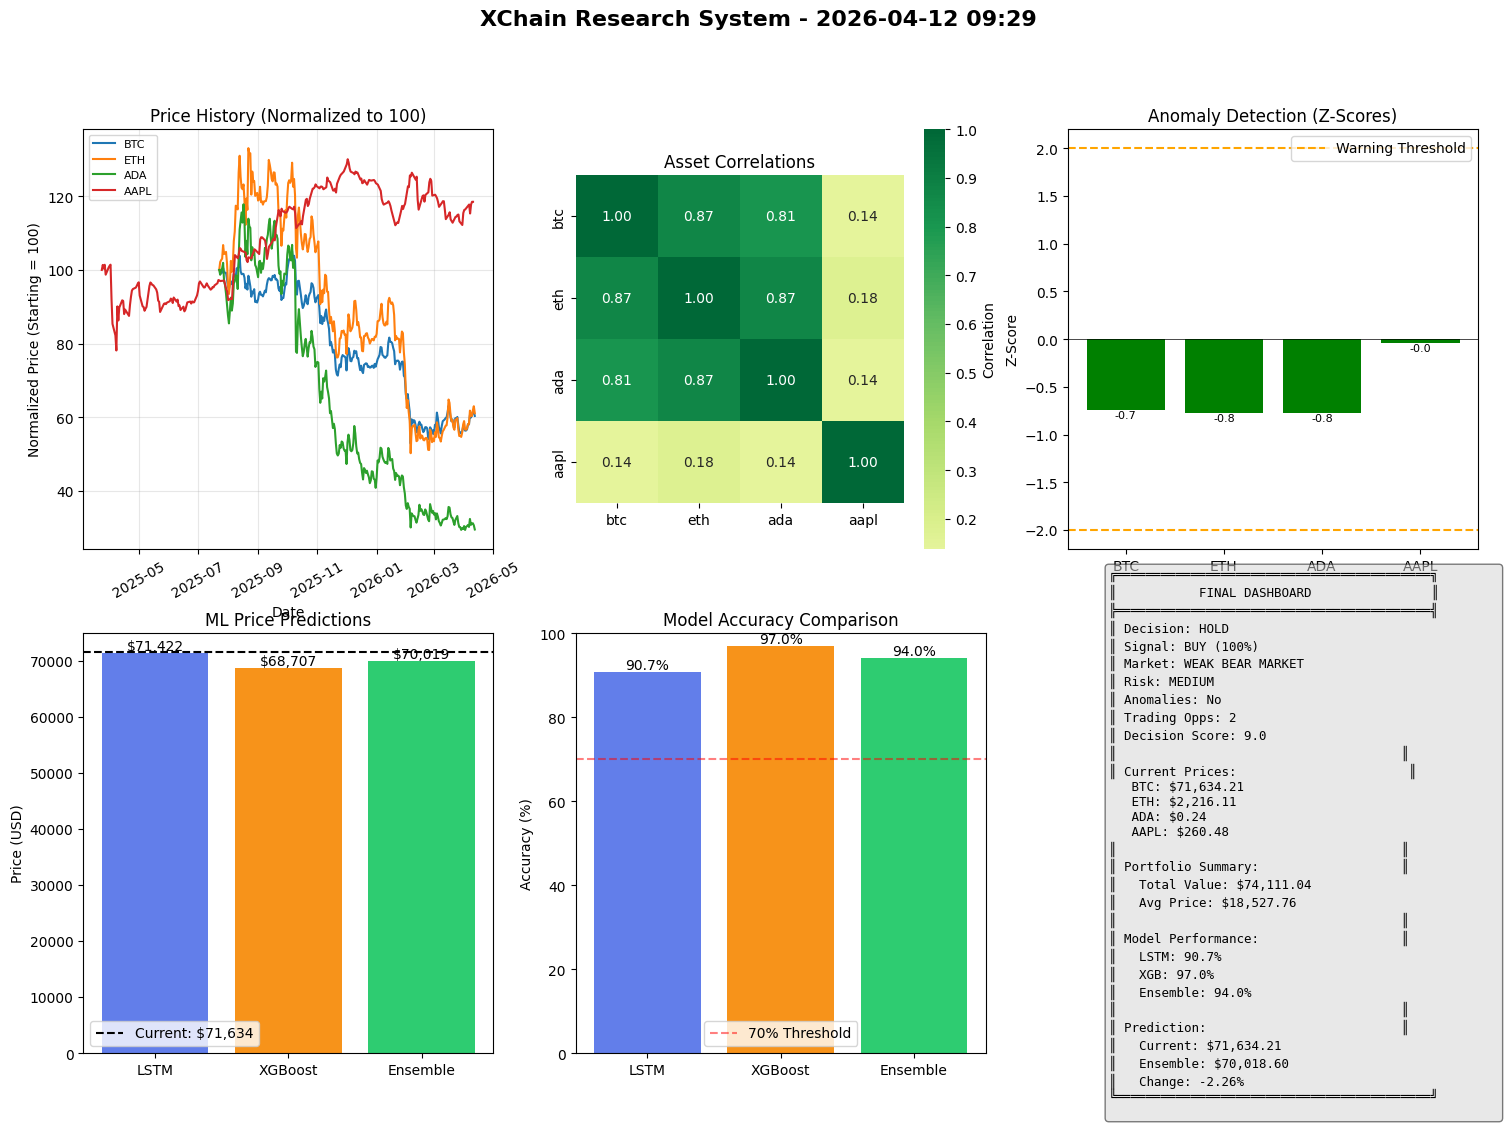

In [103]:
# CELL 17: Visualization Dashboard (FIXED - Show all assets)
def format_price(price):
    """Format price with proper commas and decimal places"""
    if price >= 1000:
        return f"${price:,.2f}"
    elif price >= 1:
        return f"${price:.2f}"
    else:
        return f"${price:.4f}"
print('\n' + '='*60)
print('📊 STAGE 11: VISUALIZATION DASHBOARD')
print('='*60)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle(f'XChain Research System - {datetime.now().strftime("%Y-%m-%d %H:%M")}',
             fontsize=16, fontweight='bold')

# 1. Price History (SHOW ALL ASSETS with better visibility)
ax = axes[0, 0]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
color_idx = 0

for name, data in market_data.items():
    if 'historical' in data:
        hist = data['historical']
        # Normalize prices to starting point for better comparison
        normalized_price = hist['price'] / hist['price'].iloc[0] * 100
        ax.plot(hist.index, normalized_price, label=name.upper(),
                linewidth=1.5, color=colors[color_idx % len(colors)])
        color_idx += 1

ax.set_title('Price History (Normalized to 100)')
ax.set_xlabel('Date')
ax.set_ylabel('Normalized Price (Starting = 100)')
ax.legend(loc='upper left', fontsize=8)
ax.tick_params(axis='x', rotation=30)
ax.grid(True, alpha=0.3)

# 2. Correlation Heatmap
ax = axes[0, 1]
sns.heatmap(correlation_matrix, annot=True, cmap='RdYlGn', center=0,
            fmt='.2f', square=True, ax=ax, cbar_kws={'label': 'Correlation'})
ax.set_title('Asset Correlations')

# 3. Anomaly Detection
ax = axes[0, 2]
anomaly_data = []
anomaly_names = []
for name, data in market_data.items():
    if 'historical' in data and 'returns' in data['historical'].columns:
        ret = data['historical']['returns']
        if len(ret) > 1 and ret.std() > 0:
            z = (ret.iloc[-1] - ret.mean()) / ret.std()
            anomaly_data.append(z)
            anomaly_names.append(name.upper())

colors_anomaly = ['red' if abs(z) > 2 else 'green' for z in anomaly_data]
bars = ax.bar(anomaly_names, anomaly_data, color=colors_anomaly)
ax.axhline(2, color='orange', linestyle='--', label='Warning Threshold')
ax.axhline(-2, color='orange', linestyle='--')
ax.axhline(0, color='black', linestyle='-', linewidth=0.5)
ax.set_title('Anomaly Detection (Z-Scores)')
ax.set_ylabel('Z-Score')
ax.legend()
for bar, z in zip(bars, anomaly_data):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'{z:.1f}', ha='center', va='bottom' if z > 0 else 'top', fontsize=8)

# 4. ML Predictions
ax = axes[1, 0]
models = ['LSTM', 'XGBoost', 'Ensemble']
preds = [lstm_prediction, xgb_next, ensemble_price]
bars = ax.bar(models, preds, color=['#627EEA', '#f7931a', '#2ecc71'])
ax.axhline(current_price, color='black', linestyle='--', label=f'Current: ${current_price:,.0f}')
ax.set_title('ML Price Predictions')
ax.set_ylabel('Price (USD)')
ax.legend()
for bar, pred in zip(bars, preds):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'${pred:,.0f}',
            ha='center', va='bottom')

# 5. Model Accuracy
ax = axes[1, 1]
models_acc = ['LSTM', 'XGBoost', 'Ensemble']
accuracies = [lstm_accuracy, xgb_accuracy, ensemble_accuracy]
colors_acc = ['#627EEA', '#f7931a', '#2ecc71']
bars_acc = ax.bar(models_acc, accuracies, color=colors_acc)
ax.axhline(70, color='red', linestyle='--', alpha=0.5, label='70% Threshold')
ax.set_title('Model Accuracy Comparison')
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, 100)
ax.legend()
for bar, acc in zip(bars_acc, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{acc:.1f}%',
            ha='center', va='bottom')
# 6. Final Dashboard with PROPER formatting (no extra spaces)
ax = axes[1, 2]
ax.axis('off')

# Build properly formatted price list
price_list = ""
price_items = []
for name, data in list(market_data.items())[:6]:
    price = data['price']
    if price >= 1000:
        price_str = f"${price:,.2f}"
    else:
        price_str = f"${price:.2f}"
    price_items.append(f"   {name.upper()}: {price_str}")

price_list = "\n".join(price_items)

# Calculate portfolio stats
portfolio_total = sum(data['price'] for data in market_data.values())
portfolio_avg = portfolio_total / len(market_data) if market_data else 0

# CRITICAL FIX: Use textwrap.dedent to remove indentation
import textwrap

dashboard_text = textwrap.dedent(f"""
╔══════════════════════════════════════════╗
║           FINAL DASHBOARD                ║
╠══════════════════════════════════════════╣
║ Decision: {decision[:25]:<25}
║ Signal: {final_signal} ({confidence:.0f}%)
║ Market: {regime[:22]:<22}
║ Risk: {risk_level}
║ Anomalies: {"Yes" if anomaly_detected else "No"}
║ Trading Opps: {total_opportunities}
║ Decision Score: {decision_score:.1f}
║                                      ║
║ Current Prices:                       ║
{price_list}
║                                      ║
║ Portfolio Summary:                   ║
║   Total Value: ${portfolio_total:,.2f}
║   Avg Price: ${portfolio_avg:,.2f}
║                                      ║
║ Model Performance:                   ║
║   LSTM: {lstm_accuracy:.1f}%
║   XGB: {xgb_accuracy:.1f}%
║   Ensemble: {ensemble_accuracy:.1f}%
║                                      ║
║ Prediction:                          ║
║   Current: ${current_price:,.2f}
║   Ensemble: ${ensemble_price:,.2f}
║   Change: {price_change_pct:+.2f}%
╚══════════════════════════════════════════╝
""")

# Remove the first character if it's a newline (cleanup)
dashboard_text = dashboard_text.lstrip('\n')

ax.text(0.1, 0.5, dashboard_text, fontsize=9, verticalalignment='center',
        fontfamily='monospace', bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.5))


In [104]:
# CELL 18: Final Summary
print('\n' + '='*60)
print('✅ XCHAIN ANALYSIS COMPLETE')
print('='*60)
print(f'📊 Analysis Timestamp: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')
print(f'🎯 Final Decision: {decision}')
print(f'📈 Signal: {final_signal} ({confidence:.0f}%)')
print(f'⚠️ Anomalies Detected: {"Yes" if anomaly_detected else "No"}')
print(f'💰 Trading Opportunities: {total_opportunities}')
print(f'📈 Decision Score: {decision_score:.1f}')
print('='*60)


✅ XCHAIN ANALYSIS COMPLETE
📊 Analysis Timestamp: 2026-04-12 09:29:21
🎯 Final Decision: HOLD
📈 Signal: BUY (100%)
⚠️ Anomalies Detected: No
💰 Trading Opportunities: 2
📈 Decision Score: 9.0


In [105]:
!pip install web3 eth-account

In [106]:
# ============================================
# BLOCKCHAIN STORAGE - Single File, Update in Place
# ============================================

print('\n' + '='*60)
print('⛓️ BLOCKCHAIN STORAGE (Single File - All Records)')
print('='*60)

import json
import hashlib
from datetime import datetime
from pathlib import Path

# Single blockchain storage file
BLOCKCHAIN_FILE = '/tmp/xchain_blockchain.json'
BLOCKCHAIN = []

# Define categories
RECORD_TYPES = {
    'SUCCESSFUL': ['AGGRESSIVE INVEST', 'INVEST', 'CAUTIOUS INVEST'],
    'HOLD': ['HOLD'],
    'AVOID': ['REDUCE EXPOSURE', 'DO NOT INVEST']
}

def get_record_type_from_decision(decision):
    """Get record type based on decision"""
    if decision in RECORD_TYPES['SUCCESSFUL']:
        return 'SUCCESSFUL'
    elif decision in RECORD_TYPES['HOLD']:
        return 'HOLD'
    else:
        return 'AVOID'

def init_blockchain():
    """Initialize blockchain from single file"""
    global BLOCKCHAIN
    if Path(BLOCKCHAIN_FILE).exists():
        try:
            with open(BLOCKCHAIN_FILE, 'r') as f:
                loaded_data = json.load(f)
                # Handle both list and dict formats
                if isinstance(loaded_data, list):
                    BLOCKCHAIN = loaded_data
                else:
                    BLOCKCHAIN = [loaded_data]
            print(f'📚 Loaded {len(BLOCKCHAIN)} existing records from single file')

            # Migrate old blocks to add missing fields
            migrated = 0
            for block in BLOCKCHAIN:
                if 'record_type' not in block:
                    decision = block['dashboard_data']['final_decision']
                    block['record_type'] = get_record_type_from_decision(decision)
                    migrated += 1

            if migrated > 0:
                # Save migrated data back to same file
                with open(BLOCKCHAIN_FILE, 'w') as f:
                    json.dump(BLOCKCHAIN, f, indent=2)
                print(f'📚 Migrated {migrated} old blocks (saved to same file)')

        except Exception as e:
            print(f'Error loading blockchain: {e}')
            BLOCKCHAIN = []
    else:
        BLOCKCHAIN = []
        print('📚 Creating new blockchain file')

def calculate_hash(block_data, previous_hash):
    """Calculate SHA-256 hash for block"""
    block_string = json.dumps(block_data, sort_keys=True) + previous_hash
    return hashlib.sha256(block_string.encode()).hexdigest()

def save_blockchain():
    """Save blockchain to file (overwrites existing file with all records)"""
    with open(BLOCKCHAIN_FILE, 'w') as f:
        json.dump(BLOCKCHAIN, f, indent=2)
    print(f'💾 Saved {len(BLOCKCHAIN)} records to {BLOCKCHAIN_FILE}')

def create_block(dashboard_data):
    """Create a new block and append to existing blockchain file"""

    record_type = get_record_type_from_decision(dashboard_data['final_decision'])

    block = {
        'block_id': len(BLOCKCHAIN) + 1,
        'timestamp': datetime.now().isoformat(),
        'unix_timestamp': int(time.time()),
        'record_type': record_type,
        'dashboard_data': dashboard_data,
        'previous_hash': BLOCKCHAIN[-1]['hash'] if BLOCKCHAIN else '0' * 64
    }

    block['hash'] = calculate_hash(block['dashboard_data'], block['previous_hash'])

    # Append to blockchain
    BLOCKCHAIN.append(block)

    # Save entire blockchain to single file (overwrite with all records)
    save_blockchain()

    return block['block_id'], record_type

def update_existing_block(block_id, updated_data):
    """Update an existing block (maintains blockchain integrity)"""
    for i, block in enumerate(BLOCKCHAIN):
        if block['block_id'] == block_id:
            # Update the dashboard data
            block['dashboard_data'].update(updated_data)
            # Recalculate hash
            block['hash'] = calculate_hash(block['dashboard_data'], block['previous_hash'])
            # Save all blocks
            save_blockchain()
            print(f'✅ Updated Block #{block_id}')
            return True
    return False

def get_block(block_id):
    """Retrieve block by ID"""
    if 1 <= block_id <= len(BLOCKCHAIN):
        return BLOCKCHAIN[block_id - 1]
    return None

def get_latest_block():
    """Get the most recent block"""
    return BLOCKCHAIN[-1] if BLOCKCHAIN else None

def get_all_blocks():
    """Get all blocks"""
    return BLOCKCHAIN

def get_blocks_by_type(record_type):
    """Get all blocks of a specific type"""
    return [b for b in BLOCKCHAIN if b.get('record_type', get_record_type_from_decision(b['dashboard_data']['final_decision'])) == record_type]

def verify_blockchain():
    """Verify blockchain integrity"""
    for i in range(1, len(BLOCKCHAIN)):
        current = BLOCKCHAIN[i]
        previous = BLOCKCHAIN[i-1]
        calculated_hash = calculate_hash(current['dashboard_data'], previous['hash'])
        if calculated_hash != current['hash']:
            return False, i
    return True, -1

def get_blockchain_stats():
    """Get statistics about all stored blocks"""
    if not BLOCKCHAIN:
        return None

    successful = get_blocks_by_type('SUCCESSFUL')
    hold = get_blocks_by_type('HOLD')
    avoid = get_blocks_by_type('AVOID')

    def safe_avg(blocks):
        scores = [b['dashboard_data']['decision_score'] for b in blocks]
        return np.mean(scores) if scores else 0

    stats = {
        'total_blocks': len(BLOCKCHAIN),
        'successful_count': len(successful),
        'hold_count': len(hold),
        'avoid_count': len(avoid),
        'successful_avg_score': safe_avg(successful),
        'hold_avg_score': safe_avg(hold),
        'avoid_avg_score': safe_avg(avoid),
        'first_block_time': BLOCKCHAIN[0]['timestamp'] if BLOCKCHAIN else None,
        'last_block_time': BLOCKCHAIN[-1]['timestamp'] if BLOCKCHAIN else None,
        'file_location': BLOCKCHAIN_FILE
    }
    return stats

# Initialize blockchain (loads existing file if exists)
init_blockchain()

# ============================================
# PREPARE DASHBOARD DATA
# ============================================

dashboard_data = {
    # Decision Summary
    'final_decision': decision,
    'signal': final_signal,
    'signal_confidence': confidence,
    'market_regime': regime,
    'risk_level': risk_level,
    'anomalies': 'No' if not anomaly_detected else 'Yes',
    'trading_opportunities': total_opportunities,
    'decision_score': decision_score,

    # Current Prices
    'current_prices': {name.upper(): data['price'] for name, data in market_data.items()},

    # Portfolio Summary
    'portfolio_total_value': portfolio_value,
    'portfolio_avg_price': portfolio_value / len(market_data) if market_data else 0,

    # Model Performance
    'model_performance': {
        'LSTM': lstm_accuracy,
        'XGB': xgb_accuracy,
        'Ensemble': ensemble_accuracy
    },

    # Prediction Details
    'current_price': current_price,
    'ensemble_prediction': ensemble_price,
    'predicted_change': price_change_pct,

    # Additional Details
    'allocation_advice': allocation_advice if 'allocation_advice' in dir() else 'N/A',
    'reason': reason,
    'arbitrage_count': len(arbitrage_ops) if 'arbitrage_ops' in dir() else 0,
    'pairs_count': len(pairs_opportunities) if 'pairs_opportunities' in dir() else 0
}

# ============================================
# STORE IN SINGLE FILE (Append/Update)
# ============================================

print(f'\n📊 Current Decision: {decision}')
record_type_map = {
    'SUCCESSFUL': '✅ SUCCESSFUL INVESTMENT',
    'HOLD': '⏸️ HOLD DECISION',
    'AVOID': '⚠️ AVOID DECISION'
}

# Check if this exact decision already exists (avoid duplicates)
def is_duplicate(new_data):
    """Check if similar decision already exists (within last hour)"""
    for block in BLOCKCHAIN:
        existing = block['dashboard_data']
        if (existing['final_decision'] == new_data['final_decision'] and
            existing['decision_score'] == new_data['decision_score'] and
            existing['signal'] == new_data['signal']):
            # Check if within last hour
            block_time = datetime.fromisoformat(block['timestamp'])
            if (datetime.now() - block_time).seconds < 3600:
                return True, block['block_id']
    return False, None

is_dup, dup_id = is_duplicate(dashboard_data)

if is_dup:
    print(f'\n⚠️ Similar decision already exists in Block #{dup_id}')
    print(f'   Updating existing block instead of creating new one...')
    update_existing_block(dup_id, dashboard_data)
    block_id = dup_id
    record_type = get_record_type_from_decision(decision)
else:
    block_id, record_type = create_block(dashboard_data)
    print(f'\n{record_type_map[record_type]} stored as Block #{block_id}')

print(f'   Timestamp: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')
print(f'   Record Type: {record_type}')
print(f'   Total Records in File: {len(BLOCKCHAIN)}')
print(f'   File Location: {BLOCKCHAIN_FILE}')

# Verify integrity
is_valid, _ = verify_blockchain()
print(f'   Blockchain Integrity: {"✅ VALID" if is_valid else "❌ CORRUPTED"}')

# ============================================
# DISPLAY BLOCK DETAILS
# ============================================

def display_block(block):
    """Display block details"""
    if not block:
        print("Block not found!")
        return

    data = block['dashboard_data']
    record_type = block.get('record_type', get_record_type_from_decision(data['final_decision']))
    type_icon = '✅' if record_type == 'SUCCESSFUL' else ('⏸️' if record_type == 'HOLD' else '⚠️')

    print(f'\n{"="*60}')
    print(f'{type_icon} BLOCK #{block["block_id"]} - {record_type}')
    print(f'{"="*60}')
    print(f'  Timestamp: {block["timestamp"]}')
    print(f'  Block Hash: {block["hash"][:40]}...')

    print(f'\n  FINAL DASHBOARD')
    print(f'  {"-"*50}')
    print(f'  Decision: {data["final_decision"]}')
    print(f'  Signal: {data["signal"]} ({data["signal_confidence"]:.0f}%)')
    print(f'  Market: {data["market_regime"]}')
    print(f'  Risk: {data["risk_level"]}')
    print(f'  Anomalies: {data["anomalies"]}')
    print(f'  Trading Opps: {data["trading_opportunities"]}')
    print(f'  Decision Score: {data["decision_score"]:.1f}')

    print(f'\n  Current Prices:')
    for asset, price in list(data["current_prices"].items())[:5]:
        print(f'    {asset}: ${price:,.2f}')

    if len(data["current_prices"]) > 5:
        print(f'    ... and {len(data["current_prices"]) - 5} more')

    print(f'\n  Portfolio Summary:')
    print(f'    Total Value: ${data["portfolio_total_value"]:,.2f}')
    print(f'    Avg Price: ${data["portfolio_avg_price"]:,.2f}')

    print(f'\n  Model Performance:')
    for model, acc in data["model_performance"].items():
        print(f'    {model}: {acc:.1f}%')

    print(f'\n  Prediction:')
    print(f'    Current: ${data["current_price"]:,.2f}')
    print(f'    Ensemble: ${data["ensemble_prediction"]:,.2f}')
    print(f'    Change: {data["predicted_change"]:+.2f}%')

    if data.get("allocation_advice") and data["allocation_advice"] != 'N/A':
        print(f'\n  Allocation Advice: {data["allocation_advice"]}')

# Display latest block
print('\n📖 LATEST RECORD:')
display_block(get_latest_block())

# ============================================
# VIEW ALL RECORDS FROM SINGLE FILE
# ============================================

def show_all_records():
    """Display all records from the single file"""
    if not BLOCKCHAIN:
        print("No records found")
        return

    print(f'\n{"="*80}')
    print(f'ALL RECORDS IN BLOCKCHAIN ({len(BLOCKCHAIN)} total)')
    print(f'{"="*80}')
    print(f'{"ID":<6} {"Type":<12} {"Decision":<20} {"Score":<8} {"Signal":<12} {"Date":<20}')
    print('-'*80)

    for block in BLOCKCHAIN:
        data = block['dashboard_data']
        record_type = block.get('record_type', get_record_type_from_decision(data['final_decision']))
        date_short = block['timestamp'][:19]
        print(f'{block["block_id"]:<6} {record_type:<12} {data["final_decision"]:<20} {data["decision_score"]:<8.1f} {data["signal"]:<12} {date_short:<20}')

show_all_records()

# ============================================
# STATISTICS
# ============================================

stats = get_blockchain_stats()
if stats:
    print('\n' + '='*60)
    print('📊 BLOCKCHAIN STATISTICS')
    print('='*60)
    print(f'  File Location: {stats["file_location"]}')
    print(f'  Total Records: {stats["total_blocks"]}')
    print(f'  ✅ Successful: {stats["successful_count"]}')
    print(f'  ⏸️ Hold: {stats["hold_count"]}')
    print(f'  ⚠️ Avoid: {stats["avoid_count"]}')

    print(f'\n  Average Decision Scores:')
    if stats["successful_count"] > 0:
        print(f'    Successful: {stats["successful_avg_score"]:.1f}')
    if stats["hold_count"] > 0:
        print(f'    Hold: {stats["hold_avg_score"]:.1f}')
    if stats["avoid_count"] > 0:
        print(f'    Avoid: {stats["avoid_avg_score"]:.1f}')

# ============================================
# EXPORT SINGLE FILE TO CSV
# ============================================

def export_to_csv():
    """Export all records from single file to CSV"""
    if not BLOCKCHAIN:
        print("No records to export")
        return None

    export_data = []
    for block in BLOCKCHAIN:
        data = block['dashboard_data']
        record_type = block.get('record_type', get_record_type_from_decision(data['final_decision']))

        export_data.append({
            'block_id': block['block_id'],
            'record_type': record_type,
            'timestamp': block['timestamp'],
            'decision': data.get('final_decision', 'N/A'),
            'decision_score': data.get('decision_score', 0),
            'signal': data.get('signal', 'N/A'),
            'confidence': data.get('signal_confidence', 0),
            'market_regime': data.get('market_regime', 'N/A'),
            'risk_level': data.get('risk_level', 'N/A'),
            'portfolio_value': data.get('portfolio_total_value', data.get('portfolio_value', 0)),
            'ensemble_prediction': data.get('ensemble_prediction', 0),
            'predicted_change': data.get('predicted_change', 0),
            'ensemble_accuracy': data.get('model_performance', {}).get('Ensemble', 0) if isinstance(data.get('model_performance'), dict) else 0
        })

    df = pd.DataFrame(export_data)
    csv_file = '/tmp/xchain_all_records.csv'
    df.to_csv(csv_file, index=False)
    print(f'\n✅ Exported {len(export_data)} records to {csv_file}')

    # Show summary
    print(f'\n📊 Export Summary:')
    print(df.groupby('record_type').size().to_string())

    return df

# Export to CSV
export_df = export_to_csv()

# ============================================
# DOWNLOAD CSV
# ============================================

def download_csv():
    """Download the single CSV file"""
    from google.colab import files
    files.download('/tmp/xchain_all_records.csv')
    print("\n✅ Download started!")

print('\n' + '='*60)
print('💡 HOW TO ACCESS THE DATA')
print('='*60)
print(f"""
1. All records are stored in a SINGLE file:
   {BLOCKCHAIN_FILE}

2. To download the CSV file:
   download_csv()

3. To view all records:
   show_all_records()

4. To get blockchain statistics:
   stats = get_blockchain_stats()

5. The file updates IN-PLACE (no duplicates):
   - Each run APPENDS a new block
   - Similar decisions within 1 hour UPDATE existing block
   - All records remain in the same file
""")

# Show file info
import os
if os.path.exists(BLOCKCHAIN_FILE):
    file_size = os.path.getsize(BLOCKCHAIN_FILE)
    print(f'\n📁 File Info:')
    print(f'   Location: {BLOCKCHAIN_FILE}')
    print(f'   Size: {file_size:,} bytes')
    print(f'   Records: {len(BLOCKCHAIN)}')


⛓️ BLOCKCHAIN STORAGE (Single File - All Records)
📚 Loaded 3 existing records from single file

📊 Current Decision: HOLD
💾 Saved 4 records to /tmp/xchain_blockchain.json

⏸️ HOLD DECISION stored as Block #4
   Timestamp: 2026-04-12 09:29:27
   Record Type: HOLD
   Total Records in File: 4
   File Location: /tmp/xchain_blockchain.json
   Blockchain Integrity: ✅ VALID

📖 LATEST RECORD:

⏸️ BLOCK #4 - HOLD
  Timestamp: 2026-04-12T09:29:27.176662
  Block Hash: 8c65f163d96b2453a51532da2a3407d3def2ed8c...

  FINAL DASHBOARD
  --------------------------------------------------
  Decision: HOLD
  Signal: BUY (100%)
  Market: WEAK BEAR MARKET
  Risk: MEDIUM
  Anomalies: No
  Trading Opps: 2
  Decision Score: 9.0

  Current Prices:
    BTC: $71,634.21
    ETH: $2,216.11
    ADA: $0.24
    AAPL: $260.48

  Portfolio Summary:
    Total Value: $74,111.04
    Avg Price: $18,527.76

  Model Performance:
    LSTM: 90.7%
    XGB: 97.0%
    Ensemble: 94.0%

  Prediction:
    Current: $71,634.21
    Ens